In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bc_init = 4*10**12
mass_extcoeff = 9*10**(-6)
radius = 6371
lower_bound = radius+16
upper_bound = radius+26
volume = 4/3*np.pi*(upper_bound**3-lower_bound**3)
folding_time = 5.5*12
extcoeff_init = mass_extcoeff*bc_init/volume
ssa_prior = 0.78425395
extcoeff_prior = 1.9851e-4
ssa_bc = 0.31

In [3]:
extcoeff_init

0.00701163040391047

In [4]:
extinction = []
for i in range(600):
    decay = np.exp(-i/folding_time)
    extinction.append(extcoeff_init*decay+extcoeff_prior)

In [5]:
months = np.arange(0,600,1)
years = np.arange(0,600,60)

In [6]:
omega = []
for i in range(600):
    omega.append((extinction[i]*ssa_bc+ssa_prior*extcoeff_prior)/(extinction[i]+extcoeff_prior))

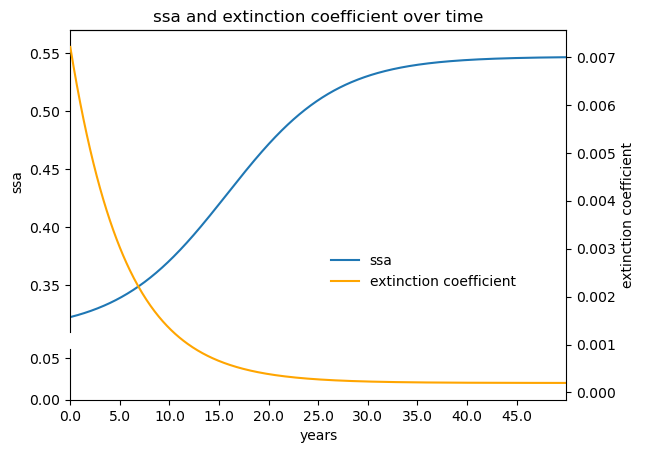

In [53]:
fig, (ax1,ax2) = plt.subplots(2,1,sharex=True, height_ratios=[.3,0.05])
fig.subplots_adjust(hspace=0.1)

ax1.plot(omega, label="ssa")
ax1.plot(extinction, color="orange", label="extinction coefficient")
ax2.plot()

ax1.set_ylim(.31,.57)
ax2.set_ylim(0,.06)
ax2.set_xlim(0,600)

ax1.spines.bottom.set_visible(False)
ax1.spines.right.set_visible(False)
ax2.spines.top.set_visible(False)
ax2.spines.right.set_visible(False)
ax1.tick_params(labeltop=False)
ax1.xaxis.set_visible(False)
ax2.xaxis.tick_bottom()
ax2.set_xticks(years,years/12)

ax1.axes.set_title("ssa and extinction coefficient over time")
ax1.axes.set_ylabel("ssa")
ax2.axes.set_xlabel("years")

ax1.legend(loc="best", bbox_to_anchor=(0.5, 0.3), frameon=False)

ax_full = fig.add_subplot(frameon=False)
ax_full.set_xticks([])
ax_full.set_yticks([])
ax_full.set_xlim(0,600)

ax3 = ax_full.twinx()
ax3.plot(extinction, color = "orange")
ax3.spines.bottom.set_visible(False)
ax3.spines.left.set_visible(False)
ax3.axes.set_ylabel("extinction coefficient")

plt.savefig("./figures/ssa.pdf")
plt.show()